### **Polynomial Basis - No Normalization**

In [53]:
import numpy as np
import matplotlib.pyplot as plt

In [54]:
data = np.loadtxt("data/noisy_2.txt")
data.shape

(10000, 2)

In [55]:
x = data[:, 0]
y = data[:, 1]

In [56]:
np.random.seed(42)

indices = np.random.permutation(len(x))

x_shuffled = x[indices]
y_shuffled = y[indices]

In [57]:
train_end = int(0.8 * len(x))

x_train = x_shuffled[:train_end]
y_train = y_shuffled[:train_end]

x_test = x_shuffled[train_end:]
y_test = y_shuffled[train_end:]

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(8000,) (8000,)
(2000,) (2000,)


In [58]:
def polynomial_basis(x, degree):
    X = np.ones((len(x), degree + 1))

    for power in range(1, degree + 1):
        X[:, power] = x ** power

    return X

test_basis = polynomial_basis(x_train, degree=3)
test_basis[:3]

array([[ 1.00000000e+00,  2.50525053e+01,  6.27628019e+02,
         1.57236542e+04],
       [ 1.00000000e+00, -6.31063106e+00,  3.98240644e+01,
        -2.51314978e+02],
       [ 1.00000000e+00, -6.53765377e+01,  4.27409168e+03,
        -2.79425315e+05]])

In [59]:
# least squares 

def least_squares_solution(X, y):

    A = X.T @ X
    b = X.T @ y

    weights = np.linalg.inv(A) @ b
    return weights

In [60]:
# prediction y_pred

def predict(X, weights):
    
    y_pred = X @ weights
    return y_pred

In [61]:
# mse

def mse(y_actual, y_pred):
    return np.mean((y_actual - y_pred) ** 2)

In [65]:
degree = 10
X_train = polynomial_basis(x_train, degree)
X_test = polynomial_basis(x_test, degree)
weights_d10 = least_squares_solution(X_train, y_train)
y_train_pred = predict(X_train, weights_d10)
y_test_pred = predict(X_test, weights_d10)

In [63]:
print(weights_d10)

[ 3.94711488e+01  6.01412547e-01 -8.62333255e-02 -6.17247286e-04
  3.59594315e-05  1.62339175e-07 -4.61851295e-09 -1.29307065e-11
  1.63800801e-13  1.64259986e-16  2.45728460e-18]


The weights in the un-normalized version is very small, becauase they have to compensate for the scale of the large magnitudes of the features.

In [66]:
print(f"Train MSE : {mse(y_train, y_train_pred):.4f}")
print(f"Test MSE : {mse(y_test, y_test_pred):.4f}")

Train MSE : 360.4778
Test MSE : 340.0071


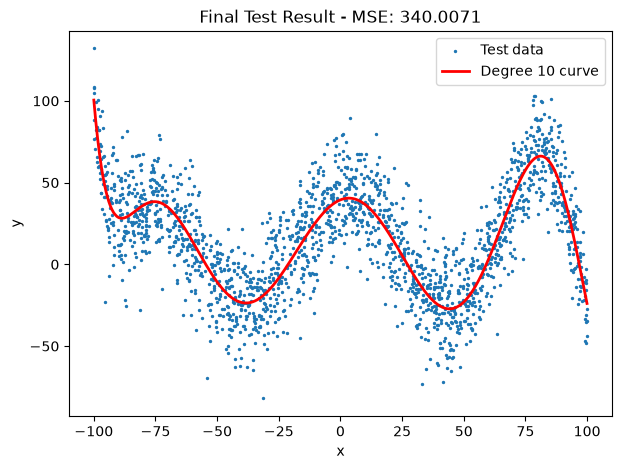

In [69]:
test_order = np.argsort(x_test)

plt.figure(figsize=(7, 5))
plt.scatter(x_test, y_test, s=2, label="Test data")
plt.plot(x_test[test_order], y_test_pred[test_order], color="red", linewidth=2, label="Degree 10 curve")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Final Test Result - MSE: {mse(y_test, y_test_pred):.4f}")
plt.legend()
plt.show()
plt.close()

Polynomial Basis without normalization and with normalization yields the same result actually. All they bring to the table is improving numerical stability and reducing floating point precision problems.

### **Gaussian Basis**